# Binary Feature Discovery from LLM Internals

Extract internal signals (router gates, Q/K/V projections, attention outputs, hidden states) from **Qwen3.5-35B-A3B-FP8** using Echo pattern, binarize them, and run supervised feature selection for late-interaction retrieval on SciFact.

**Requirements:** GPU with ≥46GB VRAM (A100 80GB, L40S, etc.)

In [1]:
# @title Install dependencies
!pip install -q vllm beir safetensors numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 433.2/433.2 MB 4.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.6/192.6 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 252.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 177.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 7.8 MB/s eta 0:00:00a 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.4/469.4 kB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# @title Configuration
import os
import sys
from pathlib import Path

# Model
MODEL_NAME = "Qwen/Qwen3.5-35B-A3B-FP8"  # @param {type:"string"}
MAX_TOKENS = 512  # @param {type:"integer"}
BATCH_SIZE = 16  # @param {type:"integer"}
GPU_MEM_UTIL = 0.90  # @param {type:"number"}
MAX_BATCHED_TOKENS = 16384  # @param {type:"integer"}

# Paths
PROJECT_ROOT = Path("/content/binary_embed")  # @param {type:"string"}
SHARD_DIR = PROJECT_ROOT / "embeddings" / "echo" / "shards"
DATASETS_DIR = PROJECT_ROOT / "datasets"
RESULTS_DIR = PROJECT_ROOT / "results"

for d in (SHARD_DIR, DATASETS_DIR, RESULTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Feature selection
MAX_DOC_TOKENS = 512  # @param {type:"integer"}
MAX_QUERY_TOKENS = 64  # @param {type:"integer"}
PREFILTER_TOP_N = 100  # @param {type:"integer"}
MAX_SELECT_STEPS = 30  # @param {type:"integer"}

# Architecture
ECHO_SEP = " "
ATTN_LAYERS = [3, 7, 11, 15, 19, 23, 27, 31, 35, 39]
NUM_LAYERS = 40
NUM_EXPERTS = 256
EXPECTED_ARCH = {
    "num_layers": 40,
    "attn_layer_indices": [3, 7, 11, 15, 19, 23, 27, 31, 35, 39],
    "hidden_size": 2048,
    "num_attention_heads": 16,
    "num_key_value_heads": 2,
    "head_dim": 256,
    "num_experts": 256,
    "num_experts_per_tok": 8,
}

print("Config OK")

Config OK


## Part 1: Signal Extraction

Uses vLLM's `worker_extension_cls` to hook into the model's forward pass and capture internal signals. The Echo pattern (text repeated twice with separator) lets us capture contextual representations from the second copy.

In [3]:
# @title Legacy worker cell (disabled)
print("Legacy embedded worker disabled. Run the next cell to write the safe worker extension.")


Legacy embedded worker disabled. Run the next cell to write the safe worker extension.


In [4]:
# @title Rewrite worker extension with safe binary shard extraction
WORKER_EXTENSION_CODE = r'''
"""vLLM worker extension — safe request-tracked binary shard extraction."""

import hashlib
import json
import os
import queue
import tempfile
import threading
from collections import deque

import numpy as np
import torch
import torch.nn.functional as F


class SignalExtractorExtension:

    def setup_hooks(self, config_json):
        config = json.loads(config_json)
        if "arch" in config:
            self.arch = config["arch"]
            options = config.get("options", {})
        else:
            self.arch = config
            options = {}

        self.capture = {}
        self.req_prompt_token_ids = {}
        self.req_capture_specs = {}
        self._req_prompt_keys = {}
        self._pending_batch_records = {}
        self._active_batch_payload = None
        self._handles = []
        self._save_error = None
        self._save_error_lock = threading.Lock()
        self._cached_segments = None
        self._cached_segment_signature = None

        self._write_queue = queue.Queue(
            maxsize=max(1, int(options.get("write_queue_size", 4))))
        self._writer_thread = threading.Thread(
            target=self._disk_writer_loop,
            daemon=True,
            name="binary-shard-writer",
        )
        self._writer_thread.start()

        model = self.model_runner.model
        text_model = model.language_model.model
        layers = list(text_model.layers)

        num_q_heads = self.arch["num_attention_heads"]
        num_kv_heads = self.arch["num_key_value_heads"]
        head_dim = self.arch["head_dim"]
        q_dim = num_q_heads * head_dim
        kv_dim = num_kv_heads * head_dim

        for layer_idx, layer in enumerate(layers):
            mlp = getattr(layer, "mlp", None)
            if mlp is not None:
                gate = getattr(mlp, "gate", None) or getattr(mlp, "router", None)
                if gate is not None:
                    def _router_hook(li):
                        def hook(_mod, _inp, out):
                            logits = out[0] if isinstance(out, tuple) else out
                            probs = F.softmax(logits.float(), dim=-1)
                            ids = probs.topk(9, dim=-1).indices.short()
                            self._append_segments(f"router_topk_ids_{li}", ids)
                        return hook
                    self._handles.append(
                        gate.register_forward_hook(_router_hook(layer_idx)))

            if layer_idx in self.arch["attn_layer_indices"]:
                attn = getattr(layer, "self_attn", None)
                if attn is not None:
                    qkv_proj = getattr(attn, "qkv_proj", None)
                    if qkv_proj is not None:
                        def _qkv_hook(li, qd, kvd, nhq, hd):
                            def hook(_mod, _inp, out):
                                t = out[0] if isinstance(out, tuple) else out
                                q_gate, k, v = t.split([qd * 2, kvd, kvd], dim=-1)
                                shape = q_gate.shape[:-1]
                                q_gate = q_gate.view(*shape, nhq, hd * 2)
                                q = q_gate[..., :hd].reshape(*shape, qd)
                                self._append_segments(f"q_{li}", q)
                                self._append_segments(f"k_{li}", k)
                                self._append_segments(f"v_{li}", v)
                            return hook
                        self._handles.append(
                            qkv_proj.register_forward_hook(
                                _qkv_hook(layer_idx, q_dim, kv_dim,
                                          num_q_heads, head_dim)))

                    o_proj = getattr(attn, "o_proj", None)
                    if o_proj is not None:
                        def _oproj_hook(li):
                            def hook(_mod, _inp, out):
                                t = out[0] if isinstance(out, tuple) else out
                                self._append_segments(f"attn_out_{li}", t)
                            return hook
                        self._handles.append(
                            o_proj.register_forward_hook(_oproj_hook(layer_idx)))

            if layer_idx == len(layers) - 1:
                def _final_hook(_li):
                    def hook(_mod, _inp, out):
                        hs = out[0] if isinstance(out, tuple) else out
                        self._append_segments("hs_final", hs)
                    return hook
                self._handles.append(
                    layer.register_forward_hook(_final_hook(layer_idx)))

        return f"Installed {len(self._handles)} hooks on {len(layers)} layers"

    @staticmethod
    def _buffer_to_numpy(buffer):
        if buffer is None:
            return None
        if hasattr(buffer, "np"):
            return np.asarray(buffer.np)
        if hasattr(buffer, "cpu"):
            return np.asarray(buffer.cpu())
        if isinstance(buffer, torch.Tensor):
            return buffer.detach().cpu().numpy()
        return np.asarray(buffer)

    @staticmethod
    def _prompt_key(token_ids):
        arr = np.asarray(token_ids, dtype=np.int32)
        return hashlib.sha1(arr.tobytes()).hexdigest()

    def _get_prompt_token_ids(self, req_index, prompt_len):
        token_ids = self.model_runner.input_batch.token_ids_cpu[req_index, :prompt_len]
        if isinstance(token_ids, torch.Tensor):
            token_ids = token_ids.detach().cpu().numpy()
        return np.asarray(token_ids, dtype=np.int32).copy()

    def _get_prompt_segments(self, tensor):
        total_tokens = tensor.shape[0]
        input_batch = self.model_runner.input_batch
        req_ids = list(input_batch.req_ids)
        num_reqs = int(getattr(input_batch, "num_reqs", len(req_ids)))
        req_ids = req_ids[:num_reqs]

        query_start_loc = getattr(self.model_runner, "query_start_loc", None)
        if query_start_loc is None:
            query_start_loc = getattr(input_batch, "query_start_loc_cpu", None)
        if query_start_loc is None:
            query_start_loc = getattr(input_batch, "query_start_loc", None)
        query_start_loc = self._buffer_to_numpy(query_start_loc)
        if query_start_loc is None:
            raise RuntimeError("query_start_loc is unavailable on this vLLM build")
        query_start_loc = query_start_loc[:num_reqs + 1]
        expected_tokens = int(query_start_loc[-1]) if len(query_start_loc) else 0
        if expected_tokens and total_tokens != expected_tokens:
            raise RuntimeError(
                f"Hook tensor token count mismatch: got {total_tokens}, expected {expected_tokens}"
            )

        num_computed_tokens = getattr(input_batch, "num_computed_tokens_cpu", None)
        if num_computed_tokens is None:
            num_computed_tokens = getattr(input_batch, "num_computed_tokens", None)
        num_computed_tokens = self._buffer_to_numpy(num_computed_tokens)
        if num_computed_tokens is None:
            num_computed_tokens = np.zeros(num_reqs, dtype=np.int64)
        num_computed_tokens = np.asarray(num_computed_tokens[:num_reqs], dtype=np.int64)

        num_prompt_tokens = self._buffer_to_numpy(getattr(input_batch, "num_prompt_tokens", None))
        if num_prompt_tokens is None:
            raise RuntimeError("num_prompt_tokens is unavailable on this vLLM build")
        num_prompt_tokens = np.asarray(num_prompt_tokens[:num_reqs], dtype=np.int64)

        signature = (
            total_tokens,
            tuple(req_ids),
            tuple(np.asarray(query_start_loc, dtype=np.int64).tolist()),
            tuple(num_computed_tokens.tolist()),
            tuple(num_prompt_tokens.tolist()),
        )
        if self._cached_segment_signature == signature:
            return self._cached_segments

        segments = []
        for req_index, req_id in enumerate(req_ids):
            if req_id is None:
                continue

            prompt_len = int(num_prompt_tokens[req_index])
            if req_id not in self.req_prompt_token_ids:
                prompt_ids = self._get_prompt_token_ids(req_index, prompt_len)
                self.req_prompt_token_ids[req_id] = prompt_ids
                prompt_key = self._prompt_key(prompt_ids)
                self._req_prompt_keys[req_id] = prompt_key
                pending = self._pending_batch_records.get(prompt_key)
                if not pending:
                    raise RuntimeError(
                        f"No prepared batch record matched prompt_key={prompt_key}"
                    )
                self.req_capture_specs[req_id] = pending.popleft()

            req_info = self.req_capture_specs.get(req_id)
            if req_info is None:
                raise RuntimeError(f"Missing capture metadata for req_id={req_id}")

            start = int(query_start_loc[req_index])
            end = int(query_start_loc[req_index + 1])
            scheduled_tokens = end - start
            prompt_tokens_done = int(num_computed_tokens[req_index])
            remaining_prompt = max(0, prompt_len - prompt_tokens_done)
            prompt_part_len = min(scheduled_tokens, remaining_prompt)
            if prompt_part_len <= 0:
                continue

            chunk_prompt_start = prompt_tokens_done
            echo_start = int(req_info["echo_start"])
            echo_end = int(req_info["echo_end"])
            capture_prompt_start = max(chunk_prompt_start, echo_start)
            capture_prompt_end = min(chunk_prompt_start + prompt_part_len, echo_end)
            if capture_prompt_start >= capture_prompt_end:
                continue

            local_start = start + (capture_prompt_start - chunk_prompt_start)
            local_end = local_start + (capture_prompt_end - capture_prompt_start)
            capture_offset = capture_prompt_start - echo_start
            segments.append((req_id, local_start, local_end, capture_offset))

        self._cached_segments = segments
        self._cached_segment_signature = signature
        return segments

    def _append_segments(self, field_name, tensor):
        segments = self._get_prompt_segments(tensor)
        for req_id, start, end, capture_offset in segments:
            req_capture = self.capture.setdefault(req_id, {})
            field_tensor = tensor[start:end].detach()
            field_entry = req_capture.get(field_name)
            if field_entry is None:
                req_info = self.req_capture_specs.get(req_id)
                if req_info is None:
                    raise RuntimeError(f"Missing capture metadata for req_id={req_id}")
                seq_len = int(req_info["echo_end"]) - int(req_info["echo_start"])
                field_entry = {
                    "tensor": torch.empty(
                        (seq_len, *field_tensor.shape[1:]),
                        dtype=field_tensor.dtype,
                        device=field_tensor.device,
                    ),
                    "filled": torch.zeros(seq_len, dtype=torch.bool, device=field_tensor.device),
                }
                req_capture[field_name] = field_entry

            next_offset = capture_offset + int(field_tensor.shape[0])
            if next_offset > field_entry["tensor"].shape[0]:
                raise RuntimeError(
                    f"Capture overflow for req_id={req_id}, field={field_name}: "
                    f"{next_offset} > {field_entry['tensor'].shape[0]}"
                )
            if bool(field_entry["filled"][capture_offset:next_offset].any().item()):
                raise RuntimeError(
                    f"Overlapping capture for req_id={req_id}, field={field_name}"
                )
            field_entry["tensor"][capture_offset:next_offset].copy_(field_tensor)
            field_entry["filled"][capture_offset:next_offset] = True

    def clear_capture(self):
        self.capture.clear()
        self.req_prompt_token_ids.clear()
        self.req_capture_specs.clear()
        self._req_prompt_keys.clear()
        self._pending_batch_records = {}
        self._active_batch_payload = None
        self._cached_segments = None
        self._cached_segment_signature = None
        return True

    def prepare_batch(self, batch_info_json):
        info = json.loads(batch_info_json)
        prompt_key_to_records = {}
        for rec in info["records"]:
            prompt_key_to_records.setdefault(rec["prompt_key"], deque()).append(dict(rec))
        self.capture = {}
        self.req_prompt_token_ids = {}
        self.req_capture_specs = {}
        self._req_prompt_keys = {}
        self._pending_batch_records = prompt_key_to_records
        self._active_batch_payload = info
        self._cached_segments = None
        self._cached_segment_signature = None
        return len(info["records"])

    def _materialize_capture(self, req_id):
        result = {}
        cap = self.capture.get(req_id, {})
        for field_name, entry in cap.items():
            if not bool(entry["filled"].all().item()):
                missing = int((~entry["filled"]).sum().item())
                raise RuntimeError(
                    f"Incomplete capture for req_id={req_id}, field={field_name}: missing {missing} tokens"
                )
            result[field_name] = entry["tensor"]
        return result

    @staticmethod
    def _pack_sign_bits(tensor):
        sign = (tensor > 0).to(torch.uint8)
        if sign.is_cuda:
            sign = sign.cpu()
        return np.packbits(sign.numpy(), axis=1)

    @staticmethod
    def _require_length(field_name, tensor, seq_len):
        if tensor is None:
            raise RuntimeError(f"Missing captured field: {field_name}")
        if int(tensor.shape[0]) != seq_len:
            raise RuntimeError(
                f"Field {field_name} has {tensor.shape[0]} tokens, expected {seq_len}"
            )
        return tensor

    def _build_record_payload(self, req_id, record):
        mat = self._materialize_capture(req_id)
        seq_len = int(record["echo_end"]) - int(record["echo_start"])
        payload = {}

        for layer_idx in range(self.arch["num_layers"]):
            key = f"router_topk_ids_{layer_idx}"
            ids = self._require_length(key, mat.get(key), seq_len)
            if ids.is_cuda:
                ids = ids.cpu()
            payload[key] = ids.numpy().astype(np.int16, copy=False)

        for layer_idx in self.arch["attn_layer_indices"]:
            for field_name in (
                f"q_{layer_idx}",
                f"k_{layer_idx}",
                f"v_{layer_idx}",
                f"attn_out_{layer_idx}",
            ):
                tensor = self._require_length(field_name, mat.get(field_name), seq_len)
                payload[field_name] = self._pack_sign_bits(tensor)

        hs = self._require_length("hs_final", mat.get("hs_final"), seq_len)
        payload["hs_final"] = self._pack_sign_bits(hs)
        return payload

    def _pack_columnar_shard(self, payloads, records):
        expected_fields = sorted(payloads[0].keys())
        for idx, payload in enumerate(payloads[1:], start=1):
            payload_fields = sorted(payload.keys())
            if payload_fields != expected_fields:
                missing = sorted(set(expected_fields) - set(payload_fields))
                extra = sorted(set(payload_fields) - set(expected_fields))
                raise RuntimeError(
                    f"Payload field mismatch for record {idx}: missing={missing}, extra={extra}"
                )

        shard_tensors = {}
        field_meta = {}
        for field in expected_fields:
            data = np.concatenate([p[field] for p in payloads], axis=0)
            shard_tensors[field] = np.asarray(data)
            field_meta[field] = {
                "encoding": "raw",
                "data_key": field,
                "data_dtype": str(shard_tensors[field].dtype),
                "shape": list(shard_tensors[field].shape),
            }

        rec_meta = []
        offset = 0
        for record in records:
            seq_len = int(record["echo_end"]) - int(record["echo_start"])
            rec_meta.append({
                "record_index": int(record["record_index"]),
                "text_id": str(record["text_id"]),
                "kind": str(record["kind"]),
                "ordinal": int(record["ordinal"]),
                "filename": str(record["filename"]),
                "token_offset": offset,
                "seq_len": seq_len,
            })
            offset += seq_len

        meta = {
            "schema_version": 1,
            "format": "binary_feature_discovery_shard",
            "num_records": len(records),
            "fields": field_meta,
            "records": rec_meta,
        }
        return shard_tensors, meta

    @staticmethod
    def _atomic_write_json(path, payload):
        directory = os.path.dirname(path)
        fd, tmp_path = tempfile.mkstemp(dir=directory, suffix=".json.tmp")
        os.close(fd)
        try:
            with open(tmp_path, "w", encoding="utf-8") as handle:
                json.dump(payload, handle, indent=2, sort_keys=True)
            os.replace(tmp_path, path)
        except Exception:
            if os.path.exists(tmp_path):
                os.unlink(tmp_path)
            raise

    def _save_shard(self, data_path, meta_path, shard_tensors, meta):
        from safetensors.numpy import save_file
        directory = os.path.dirname(data_path)
        fd, tmp_data = tempfile.mkstemp(dir=directory, suffix=".safetensors.tmp")
        os.close(fd)
        try:
            save_file(shard_tensors, tmp_data)
            os.replace(tmp_data, data_path)
        except Exception:
            if os.path.exists(tmp_data):
                os.unlink(tmp_data)
            raise
        self._atomic_write_json(meta_path, meta)

    def _set_save_error(self, exc):
        with self._save_error_lock:
            if self._save_error is None:
                self._save_error = exc

    def _disk_writer_loop(self):
        while True:
            item = self._write_queue.get()
            try:
                if item is None:
                    return
                data_path, meta_path, shard_tensors, meta = item
                self._save_shard(data_path, meta_path, shard_tensors, meta)
            except Exception as exc:
                self._set_save_error(exc)
            finally:
                self._write_queue.task_done()

    def _raise_save_error_if_any(self):
        with self._save_error_lock:
            if self._save_error is None:
                return
            err = self._save_error
            self._save_error = None
        raise RuntimeError(f"Save failed: {err}")

    def transfer_and_save_async(self):
        self._raise_save_error_if_any()
        info = self._active_batch_payload
        if info is None:
            raise RuntimeError("No prepared batch is active")
        if len(self.req_capture_specs) != len(info["records"]):
            raise RuntimeError(
                f"Expected {len(info['records'])} captured requests, found {len(self.req_capture_specs)}"
            )

        matched = sorted(
            self.req_capture_specs.items(),
            key=lambda item: int(item[1]["record_index"]),
        )
        payloads = []
        records = []
        for req_id, record in matched:
            payloads.append(self._build_record_payload(req_id, record))
            records.append(record)

        if payloads:
            shard_tensors, meta = self._pack_columnar_shard(payloads, records)
            self._write_queue.put((
                info["shard_data_path"],
                info["shard_meta_path"],
                shard_tensors,
                meta,
            ))
        return len(payloads)

    def flush_saves(self):
        self._write_queue.join()
        self._raise_save_error_if_any()
        return True

    def get_captured_payload(self):
        if self._active_batch_payload is None:
            raise RuntimeError("No prepared batch is active")
        if len(self.req_capture_specs) != 1:
            raise RuntimeError(
                f"Expected exactly one captured request, found {len(self.req_capture_specs)}"
            )
        req_id, record = next(iter(self.req_capture_specs.items()))
        return self._build_record_payload(req_id, record)

    def get_architecture(self):
        model = self.model_runner.model
        text_model = model.language_model.model
        layers = list(text_model.layers)
        config = text_model.config
        layer_types = []
        attn_layer_indices = []
        for idx, layer in enumerate(layers):
            lt = getattr(layer, "layer_type", None)
            if lt is None and hasattr(config, "layer_types"):
                lt = config.layer_types[idx]
            layer_types.append(lt)
            if lt == "full_attention":
                attn_layer_indices.append(idx)
        return json.dumps({
            "model_class": type(model).__name__,
            "num_layers": len(layers),
            "layer_types": layer_types,
            "attn_layer_indices": attn_layer_indices,
            "hidden_size": int(config.hidden_size),
            "num_attention_heads": int(config.num_attention_heads),
            "num_key_value_heads": int(config.num_key_value_heads),
            "head_dim": int(config.head_dim),
            "num_experts": int(config.num_experts),
            "num_experts_per_tok": int(config.num_experts_per_tok),
        })

    def remove_hooks(self):
        self.flush_saves()
        self._write_queue.put(None)
        self._writer_thread.join()
        for handle in self._handles:
            handle.remove()
        self._handles.clear()
        self.clear_capture()
        return True
'''

worker_path = PROJECT_ROOT / "worker_extension_nb.py"
worker_path.write_text(WORKER_EXTENSION_CODE, encoding="utf-8")
print(f"Rewrote worker extension to {worker_path}")


Rewrote worker extension to /content/binary_embed/worker_extension_nb.py


In [5]:
# @title Load dataset
from beir import util
from beir.datasets.data_loader import GenericDataLoader

url = "https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/scifact.zip"
data_path = util.download_and_unzip(url, str(DATASETS_DIR))
corpus, queries, qrels = GenericDataLoader(data_path).load(split="test")
print(f"Corpus: {len(corpus)}, Queries: {len(queries)}, Qrels: {len(qrels)}")

/usr/local/lib/python3.12/dist-packages/beir/util.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


/content/binary_embed/datasets/scifact.zip:   0%|          | 0.00/2.69M [00:00<?, ?iB/s]

  0%|          | 0/5183 [00:00<?, ?it/s]

Corpus: 5183, Queries: 300, Qrels: 300


In [6]:
# @title Build text list
import hashlib
import numpy as np

def _sort_key(text_id):
    if text_id.isdigit():
        return (0, f"{int(text_id):020d}")
    return (1, text_id)

def build_texts(corpus, queries, limit_docs=None, limit_queries=None):
    texts = []
    sorted_docs = sorted(corpus.items(), key=lambda x: _sort_key(str(x[0])))
    if limit_docs is not None:
        sorted_docs = sorted_docs[:limit_docs]
    for ordinal, (doc_id, doc) in enumerate(sorted_docs, start=1):
        title = doc.get("title", "").strip()
        body = doc.get("text", "").strip()
        texts.append(("doc", ordinal, str(doc_id),
                      f"{title}. {body}".strip(), f"doc_{ordinal:07d}.pt"))
    sorted_queries = sorted(queries.items(), key=lambda x: _sort_key(str(x[0])))
    if limit_queries is not None:
        sorted_queries = sorted_queries[:limit_queries]
    for ordinal, (qid, text) in enumerate(sorted_queries, start=1):
        texts.append(("query", ordinal, str(qid), str(text),
                      f"query_{ordinal:06d}.pt"))
    return texts

def build_echo_token_ids(tokenizer, text, max_tokens):
    original_ids = tokenizer.encode(text, add_special_tokens=False)[:max_tokens]
    sep_ids = tokenizer.encode(ECHO_SEP, add_special_tokens=False)
    return original_ids + sep_ids + original_ids, len(original_ids), len(sep_ids)

def prompt_key(token_ids):
    arr = np.asarray(token_ids, dtype=np.int32)
    return hashlib.sha1(arr.tobytes()).hexdigest()

texts = build_texts(corpus, queries)
print(f"Total texts: {len(texts)} ({sum(1 for t in texts if t[0]=='doc')} docs, "
      f"{sum(1 for t in texts if t[0]=='query')} queries)")

Total texts: 5483 (5183 docs, 300 queries)


In [7]:
# @title Load model + install hooks
import json
import time

os.environ["VLLM_ENABLE_V1_MULTIPROCESSING"] = "0"
os.environ["VLLM_ALLOW_INSECURE_SERIALIZATION"] = "1"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
sys.path.insert(0, str(PROJECT_ROOT))

# Patch vLLM's suppress_stdout which calls fileno() — unsupported in Jupyter
import contextlib
import vllm.utils.system_utils
@contextlib.contextmanager
def _noop_suppress():
    yield
vllm.utils.system_utils.suppress_stdout = _noop_suppress

# Also patch in parallel_state where it's already imported
import vllm.distributed.parallel_state
vllm.distributed.parallel_state.suppress_stdout = _noop_suppress

from vllm import LLM, SamplingParams, TokensPrompt

print(f"Loading model: {MODEL_NAME}")
llm = LLM(
    model=MODEL_NAME,
    enforce_eager=True,
    gpu_memory_utilization=GPU_MEM_UTIL,
    max_model_len=2 * MAX_TOKENS + 32,
    trust_remote_code=True,
    worker_extension_cls="worker_extension_nb.SignalExtractorExtension",
    enable_chunked_prefill=True,
    max_num_batched_tokens=MAX_BATCHED_TOKENS,
)
tokenizer = llm.get_tokenizer()
sampling = SamplingParams(max_tokens=1, temperature=0.0, detokenize=False)

arch = json.loads(llm.collective_rpc("get_architecture")[0])
for key, expected in EXPECTED_ARCH.items():
    assert arch.get(key) == expected, f"Arch mismatch: {key}={arch.get(key)}, expected {expected}"
print("Architecture verified OK")

hook_config = {
    "arch": arch,
    "options": {
        "shard_format": "safetensors",
        "activation_quantization": "int8",
    },
}
print(llm.collective_rpc("setup_hooks", args=(json.dumps(hook_config),))[0])

Loading model: Qwen/Qwen3.5-35B-A3B-FP8
INFO 03-26 01:28:44 [utils.py:233] non-default args: {'trust_remote_code': True, 'max_model_len': 1056, 'max_num_batched_tokens': 16384, 'disable_log_stats': True, 'enforce_eager': True, 'enable_chunked_prefill': True, 'worker_extension_cls': 'worker_extension_nb.SignalExtractorExtension', 'model': 'Qwen/Qwen3.5-35B-A3B-FP8'}


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

WARNING 03-26 01:28:55 [arg_utils.py:1352] The global random seed is set to 0. Since VLLM_ENABLE_V1_MULTIPROCESSING is set to False, this may affect the random state of the Python process that launched vLLM.


The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.


...

WARNING 03-26 01:32:41 [fused_moe.py:1093] Using default MoE config. Performance might be sub-optimal! Config file not found at /usr/local/lib/python3.12/dist-packages/vllm/model_executor/layers/fused_moe/configs/E=256,N=512,device_name=NVIDIA_RTX_PRO_6000_Blackwell_Server_Edition,dtype=fp8_w8a8,block_shape=[128,128].json


/usr/local/lib/python3.12/dist-packages/vllm/model_executor/layers/fla/ops/utils.py:113: UserWarning: Input tensor shape suggests potential format mismatch: seq_len (16) < num_heads (32). This may indicate the inputs were passed in head-first format [B, H, T, ...] when head_first=False was specified. Please verify your input tensor format matches the expected shape [B, T, H, ...].
  return fn(*contiguous_args, **contiguous_kwargs)
/usr/local/lib/python3.12/dist-packages/vllm/model_executor/layers/fla/ops/utils.py:113: UserWarning: Input tensor shape suggests potential format mismatch: seq_len (16) < num_heads (32). This may indicate the inputs were passed in head-first format [B, H, T, ...] when head_first=False was specified. Please verify your input tensor format matches the expected shape [B, T, H, ...].
  return fn(*contiguous_args, **contiguous_kwargs)


INFO 03-26 01:32:48 [gpu_worker.py:456] Available KV cache memory: 42.23 GiB
INFO 03-26 01:32:48 [kv_cache_utils.py:1316] GPU KV cache size: 553,344 tokens
INFO 03-26 01:32:48 [kv_cache_utils.py:1321] Maximum concurrency for 1,056 tokens per request: 524.00x


2026-03-26 01:32:49,026 - INFO - autotuner.py:262 - flashinfer.jit: [Autotuner]: Autotuning process starts ...
2026-03-26 01:32:49,092 - INFO - autotuner.py:268 - flashinfer.jit: [Autotuner]: Autotuning process ends


INFO 03-26 01:32:49 [core.py:281] init engine (profile, create kv cache, warmup model) took 72.21 seconds
INFO 03-26 01:32:50 [llm.py:391] Supported tasks: ('generate',)
Architecture verified OK
Installed 61 hooks on 40 layers


In [8]:
# @title Smoke test
echo_ids, N, sep_len = build_echo_token_ids(tokenizer, "Test sentence.", MAX_TOKENS)
assert echo_ids[:N] == echo_ids[N + sep_len:], "Echo token mismatch"

test_info = {
    "shard_data_path": "/dev/null",
    "shard_meta_path": "/dev/null",
    "records": [{
        "prompt_key": prompt_key(echo_ids),
        "echo_start": N + sep_len,
        "echo_end": N + sep_len + N,
        "text_id": "test", "kind": "test",
        "ordinal": 0, "filename": "test", "record_index": 0,
    }],
}
llm.collective_rpc("clear_capture")
llm.collective_rpc("prepare_batch", args=(json.dumps(test_info),))
llm.generate([TokensPrompt(prompt_token_ids=echo_ids)], sampling_params=sampling)
tp = llm.collective_rpc("get_captured_payload")[0]

print(f"Tokens: {N}, Echo: {len(echo_ids)}, Payload keys: {len(tp)}")
for key in sorted(tp):
    v = tp[key]
    if isinstance(v, np.ndarray) and v.ndim > 0:
        print(f"  {key}: {v.shape} {v.dtype}")

Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: Input tensor shape suggests potential format mismatch: seq_len (7) < num_heads (16). This may indicate the inputs were passed in head-first format [B, H, T, ...] Please verify your input tensor format matches the expected shape [B, T, H, ...].
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/vllm/model_executor/layers/fla/ops/utils.py:113: UserWarning: Input tensor shape suggests potential format mismatch: seq_len (7) < num_heads (32). This may indicate the inputs were passed in head-first format [B, H, T, ...] when head_first=False was specified. Please verify your input tensor format matches the expected shape [B, T, H, ...].
  return fn(*contiguous_args, **contiguous_kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: Input tensor shape suggests potential format mismatch: seq_len (7) < num_heads (16). This may indicate the inputs were 

Tokens: 3, Echo: 7, Payload keys: 81
  attn_out_11: (3, 256) uint8
  attn_out_15: (3, 256) uint8
  attn_out_19: (3, 256) uint8
  attn_out_23: (3, 256) uint8
  attn_out_27: (3, 256) uint8
  attn_out_3: (3, 256) uint8
  attn_out_31: (3, 256) uint8
  attn_out_35: (3, 256) uint8
  attn_out_39: (3, 256) uint8
  attn_out_7: (3, 256) uint8
  hs_final: (3, 256) uint8
  k_11: (3, 64) uint8
  k_15: (3, 64) uint8
  k_19: (3, 64) uint8
  k_23: (3, 64) uint8
  k_27: (3, 64) uint8
  k_3: (3, 64) uint8
  k_31: (3, 64) uint8
  k_35: (3, 64) uint8
  k_39: (3, 64) uint8
  k_7: (3, 64) uint8
  q_11: (3, 512) uint8
  q_15: (3, 512) uint8
  q_19: (3, 512) uint8
  q_23: (3, 512) uint8
  q_27: (3, 512) uint8
  q_3: (3, 512) uint8
  q_31: (3, 512) uint8
  q_35: (3, 512) uint8
  q_39: (3, 512) uint8
  q_7: (3, 512) uint8
  router_topk_ids_0: (3, 9) int16
  router_topk_ids_1: (3, 9) int16
  router_topk_ids_10: (3, 9) int16
  router_topk_ids_11: (3, 9) int16
  router_topk_ids_12: (3, 9) int16
  router_topk_ids_1

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: Input tensor shape suggests potential format mismatch: seq_len (7) < num_heads (16). This may indicate the inputs were passed in head-first format [B, H, T, ...] Please verify your input tensor format matches the expected shape [B, T, H, ...].
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/vllm/model_executor/layers/fla/ops/utils.py:113: UserWarning: Input tensor shape suggests potential format mismatch: seq_len (7) < num_heads (32). This may indicate the inputs were passed in head-first format [B, H, T, ...] when head_first=False was specified. Please verify your input tensor format matches the expected shape [B, T, H, ...].
  return fn(*contiguous_args, **contiguous_kwargs)


In [9]:
# Quick debug: check if hooks are capturing anything
llm.collective_rpc("clear_capture")
llm.collective_rpc("prepare_batch", args=(json.dumps(test_info),))
llm.generate([TokensPrompt(prompt_token_ids=echo_ids)], sampling_params=sampling)

# Check capture state via a quick RPC
debug_code = """
def debug_capture(self):
    import json
    return json.dumps({
        "capture_keys": list(self.capture.keys()),
        "num_captures": {k: len(v) for k, v in self.capture.items()} if self.capture else {},
        "req_prompt_keys": dict(self._req_prompt_keys),
        "pending_records": {k: v.get("prompt_key", "?") for k, v in self._pending_batch_records.items()},
    })
"""
# Can't add methods dynamically via RPC, so let's check via get_captured_payload internals
# Instead, let's check if the worker extension file on disk is the updated version
import worker_extension_nb
import inspect
src = inspect.getsource(worker_extension_nb.SignalExtractorExtension._get_prompt_segments)
print("Has prompt key caching:", "_req_prompt_keys" in src)
print("Source preview:", src[:200])


Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Has prompt key caching: True
Source preview:     def _get_prompt_segments(self, tensor):
        total_tokens = tensor.shape[0]
        input_batch = self.model_runner.input_batch
        req_ids = list(input_batch.req_ids)
        num_reqs = in


In [10]:
# @title Run full extraction
import csv

# Prepare all records
prepared = []
for kind, ordinal, text_id, text, filename in texts:
    echo_ids, orig_len, sep_len = build_echo_token_ids(tokenizer, text, MAX_TOKENS)
    echo_ids_arr = np.asarray(echo_ids, dtype=np.int32)
    echo_start = orig_len + sep_len
    echo_end = echo_start + orig_len
    prepared.append({
        "kind": kind, "ordinal": ordinal, "text_id": text_id,
        "filename": filename, "echo_ids": echo_ids_arr,
        "prompt_key": prompt_key(echo_ids),
        "echo_start": echo_start, "echo_end": echo_end,
        "seq_len": echo_end - echo_start,
    })
print(f"Prepared {len(prepared)} texts")

def shard_paths(shard_dir, batch_idx):
    stem = f"batch_{batch_idx:06d}"
    return (
        str(shard_dir / f"{stem}.safetensors"),
        str(shard_dir / f"{stem}.json"),
        stem,
    )

# Extract
t_start = time.perf_counter()
done = 0
skipped = 0
manifest_rows = []
shard_rows = []

for batch_idx, batch_start in enumerate(range(0, len(prepared), BATCH_SIZE)):
    batch = prepared[batch_start:batch_start + BATCH_SIZE]
    if not batch:
        continue

    data_path, meta_path, shard_stem = shard_paths(SHARD_DIR, batch_idx)

    # Track manifest
    seq_offset = 0
    for ri, rec in enumerate(batch):
        manifest_rows.append({
            "kind": rec["kind"], "ordinal": rec["ordinal"],
            "text_id": rec["text_id"], "filename": rec["filename"],
            "shard_stem": shard_stem, "shard_file": data_path,
            "meta_file": meta_path, "record_index": ri,
            "token_offset": seq_offset, "seq_len": rec["seq_len"],
            "storage_format": "safetensors",
        })
        seq_offset += rec["seq_len"]
    shard_rows.append({
        "shard_stem": shard_stem, "shard_file": data_path,
        "meta_file": meta_path, "num_records": len(batch),
        "num_tokens": seq_offset, "storage_format": "safetensors",
    })

    # Skip if already exists
    if os.path.exists(data_path) and os.path.exists(meta_path):
        skipped += len(batch)
        done += len(batch)
        continue

    # Build prompts
    batch_records = []
    prompt_ids_list = []
    for ri, rec in enumerate(batch):
        prompt_ids_list.append(rec["echo_ids"].tolist())
        batch_records.append({
            "prompt_key": rec["prompt_key"],
            "echo_start": rec["echo_start"],
            "echo_end": rec["echo_end"],
            "text_id": rec["text_id"], "kind": rec["kind"],
            "ordinal": rec["ordinal"], "filename": rec["filename"],
            "record_index": ri,
        })

    batch_info = {
        "shard_data_path": data_path,
        "shard_meta_path": meta_path,
        "records": batch_records,
    }

    llm.collective_rpc("clear_capture")
    llm.collective_rpc("prepare_batch", args=(json.dumps(batch_info),))
    prompts = [TokensPrompt(prompt_token_ids=ids) for ids in prompt_ids_list]
    llm.generate(prompts, sampling_params=sampling)
    saved_count = llm.collective_rpc("transfer_and_save_async")[0]
    if saved_count != len(batch):
        raise RuntimeError(
            f"Worker saved {saved_count} records for a batch of {len(batch)}"
        )
    done += len(batch)

    elapsed = time.perf_counter() - t_start
    processed = done - skipped
    rate = processed / max(elapsed, 1e-6)
    remaining = ((len(prepared) - done) / max(rate, 1e-6)) if rate > 0 else 0
    if done % (BATCH_SIZE * 5) == 0 or done >= len(prepared):
        print(f"  [{done}/{len(prepared)}] {elapsed:.0f}s, ~{remaining:.0f}s left, {rate:.1f} t/s")

llm.collective_rpc("flush_saves")
elapsed = time.perf_counter() - t_start
print(f"\nDone. {done} texts in {elapsed:.1f}s ({skipped} resumed)")

# Write manifests
manifest_path = RESULTS_DIR / "records.csv"
with manifest_path.open("w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(manifest_rows[0].keys()))
    w.writeheader()
    w.writerows(manifest_rows)

shard_manifest_path = RESULTS_DIR / "shards.csv"
with shard_manifest_path.open("w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(shard_rows[0].keys()))
    w.writeheader()
    w.writerows(shard_rows)

print(f"Manifest: {manifest_path}")
print(f"Shard manifest: {shard_manifest_path}")

Prepared 5483 texts


Rendering prompts:   0%|          | 0/16 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/16 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Rendering prompts:   0%|          | 0/16 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/16 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

...

Rendering prompts:   0%|          | 0/16 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/16 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Rendering prompts:   0%|          | 0/11 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/11 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

  [5483/5483] 142s, ~0s left, 38.7 t/s

Done. 5483 texts in 141.7s (0 resumed)
Manifest: /content/binary_embed/results/records.csv
Shard manifest: /content/binary_embed/results/shards.csv


In [11]:
# @title Free GPU memory
llm.collective_rpc("remove_hooks")
del llm
import gc, torch
gc.collect()
torch.cuda.empty_cache()
print("GPU memory freed")

GPU memory freed


---
## Part 2: Binarization & Feature Discovery

No GPU needed from here. Load shards, binarize signals into packed bit arrays, compute per-group MaxSim score matrices, then find optimal combinations via greedy forward selection on precomputed scores (instant per evaluation).

In [12]:
# @title Feature group definitions
import numpy as np
import csv
import json
import time
from pathlib import Path
from collections import defaultdict
from safetensors.numpy import load_file

_POPCOUNT_TABLE = np.array([bin(i).count('1') for i in range(256)], dtype=np.uint8)

def define_feature_groups():
    groups = []
    for l in range(NUM_LAYERS):
        groups.append({
            "name": f"router_{l}", "type": "router", "layer": l,
            "num_bits": NUM_EXPERTS, "packed_bytes": NUM_EXPERTS // 8,
        })
    for l in ATTN_LAYERS:
        groups.append({
            "name": f"q_sign_{l}", "type": "sign", "field": f"q_{l}",
            "layer": l, "num_bits": 4096, "packed_bytes": 512,
        })
        groups.append({
            "name": f"k_sign_{l}", "type": "sign", "field": f"k_{l}",
            "layer": l, "num_bits": 512, "packed_bytes": 64,
        })
        groups.append({
            "name": f"v_sign_{l}", "type": "sign", "field": f"v_{l}",
            "layer": l, "num_bits": 512, "packed_bytes": 64,
        })
        groups.append({
            "name": f"attn_out_sign_{l}", "type": "sign",
            "field": f"attn_out_{l}", "layer": l,
            "num_bits": 2048, "packed_bytes": 256,
        })
    groups.append({
        "name": "hs_final_sign", "type": "sign", "field": "hs_final",
        "layer": -1, "num_bits": 2048, "packed_bytes": 256,
    })
    return groups

groups = define_feature_groups()
groups_lookup = {g["name"]: g for g in groups}
print(f"{len(groups)} feature groups, {sum(g['num_bits'] for g in groups)} total candidate bits")

81 feature groups, 83968 total candidate bits


In [13]:
# @title Load shards and binarize

def binarize_router_topk(tensors, meta, offset, length, layer_idx):
    """Router top-9 ids → 256-bit indicator per token."""
    field_name = f"router_topk_ids_{layer_idx}"
    field_info = meta["fields"].get(field_name)
    if field_info is None:
        raise KeyError(f"Missing field in shard metadata: {field_name}")
    ids = tensors[field_info["data_key"]][offset:offset + length]
    if ids.shape[0] != length:
        raise RuntimeError(
            f"Field {field_name} has {ids.shape[0]} rows, expected {length}"
        )
    seq_len = ids.shape[0]
    bits = np.zeros((seq_len, NUM_EXPERTS), dtype=np.uint8)
    for k in range(ids.shape[1]):
        col = ids[:, k].astype(np.int32)
        valid = (col >= 0) & (col < NUM_EXPERTS)
        rows = np.arange(seq_len)[valid]
        bits[rows, col[valid]] = 1
    return np.packbits(bits, axis=1)

def load_packed_sign_bits(tensors, meta, offset, length, field_name):
    """Load prepacked sign bits written during extraction."""
    field_info = meta["fields"].get(field_name)
    if field_info is None:
        raise KeyError(f"Missing field in shard metadata: {field_name}")
    data = tensors[field_info["data_key"]][offset:offset + length]
    if data.shape[0] != length:
        raise RuntimeError(
            f"Field {field_name} has {data.shape[0]} rows, expected {length}"
        )
    return np.asarray(data, dtype=np.uint8)

# Load records manifest
records = []
with open(RESULTS_DIR / "records.csv") as f:
    for row in csv.DictReader(f):
        row["ordinal"] = int(row["ordinal"])
        row["record_index"] = int(row["record_index"])
        row["token_offset"] = int(row["token_offset"])
        row["seq_len"] = int(row["seq_len"])
        records.append(row)

shard_records = defaultdict(list)
for rec in records:
    shard_records[rec["shard_stem"]].append(rec)

# Binarize all texts
docs = {}     # text_id → {group_name: packed_bits (seq_len, packed_bytes)}
queries_bin = {}  # text_id → {group_name: packed_bits}
done = 0
total = len(records)
t0 = time.perf_counter()

for shard_stem, recs in sorted(shard_records.items()):
    shard_path = SHARD_DIR / f"{shard_stem}.safetensors"
    meta_path = SHARD_DIR / f"{shard_stem}.json"
    meta = json.loads(meta_path.read_text())
    tensors = load_file(str(shard_path))

    for rec in recs:
        max_tok = MAX_QUERY_TOKENS if rec["kind"] == "query" else MAX_DOC_TOKENS
        length = min(rec["seq_len"], max_tok)
        offset = rec["token_offset"]

        bits = {}
        for g in groups:
            if g["type"] == "router":
                bits[g["name"]] = binarize_router_topk(
                    tensors, meta, offset, length, g["layer"])
            elif g["type"] == "sign":
                bits[g["name"]] = load_packed_sign_bits(
                    tensors, meta, offset, length, g["field"])

        if rec["kind"] == "doc":
            docs[rec["text_id"]] = bits
        else:
            queries_bin[rec["text_id"]] = bits
        done += 1

    if done % 500 == 0 or done == total:
        print(f"  Binarized {done}/{total} ({time.perf_counter()-t0:.1f}s)")
    del tensors

print(f"\nDocs: {len(docs)}, Queries: {len(queries_bin)}")

# Load qrels (needed for evaluation even if Part 1 was skipped)
from beir import util
from beir.datasets.data_loader import GenericDataLoader
url = "https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/scifact.zip"
data_path = util.download_and_unzip(url, str(DATASETS_DIR))
_, _, qrels = GenericDataLoader(data_path).load(split="test")
print(f"Qrels: {len(qrels)} queries with relevance judgments")

  Binarized 2000/5483 (5.8s)
  Binarized 4000/5483 (11.8s)
  Binarized 5483/5483 (15.6s)

Docs: 5183, Queries: 300


  0%|          | 0/5183 [00:00<?, ?it/s]

Qrels: 300 queries with relevance judgments


In [14]:
# @title Compute per-group MaxSim score matrices
# This is the expensive step — done once. After this, feature selection is instant.

doc_ids = sorted(docs.keys())
query_ids = sorted(queries_bin.keys())
num_q = len(query_ids)
num_d = len(doc_ids)
doc_id_to_idx = {did: i for i, did in enumerate(doc_ids)}

def maxsim_one_pair(q_bits, d_bits):
    """MaxSim: mean over q_tokens of max over d_tokens of hamming agreement."""
    xor = np.bitwise_xor(q_bits[:, None, :], d_bits[None, :, :])
    hamming_dist = _POPCOUNT_TABLE[xor].astype(np.uint16).sum(axis=2)
    total_bits = q_bits.shape[1] * 8
    return (total_bits - hamming_dist.min(axis=1).astype(np.float32)).mean()

def compute_group_scores(group_name, prefilter_n=PREFILTER_TOP_N):
    """Compute MaxSim score matrix for one feature group."""
    packed_bytes = docs[doc_ids[0]][group_name].shape[1]
    num_bits = packed_bytes * 8

    # Single-vector prefilter
    doc_vecs = np.zeros((num_d, num_bits), dtype=np.float32)
    for i, did in enumerate(doc_ids):
        doc_vecs[i] = np.unpackbits(docs[did][group_name], axis=1).astype(np.float32).mean(axis=0)

    query_vecs = np.zeros((num_q, num_bits), dtype=np.float32)
    for i, qid in enumerate(query_ids):
        query_vecs[i] = np.unpackbits(queries_bin[qid][group_name], axis=1).astype(np.float32).mean(axis=0)

    sv_scores = query_vecs @ doc_vecs.T
    top_n = min(prefilter_n, num_d)
    if top_n >= num_d:
        prefilter_idx = np.broadcast_to(
            np.arange(num_d, dtype=np.int32), (num_q, num_d))
    else:
        prefilter_idx = np.argpartition(-sv_scores, top_n - 1, axis=1)[:, :top_n]

    # MaxSim on prefiltered
    scores = np.zeros((num_q, num_d), dtype=np.float32)
    for qi in range(num_q):
        q_bits = queries_bin[query_ids[qi]][group_name]
        for di in prefilter_idx[qi]:
            d_bits = docs[doc_ids[di]][group_name]
            scores[qi, di] = maxsim_one_pair(q_bits, d_bits)

    return scores

# Compute all group score matrices
group_scores = {}
t0 = time.perf_counter()
for i, g in enumerate(groups):
    gt0 = time.perf_counter()
    group_scores[g["name"]] = compute_group_scores(g["name"])
    elapsed = time.perf_counter() - gt0
    if (i + 1) % 10 == 0 or i == len(groups) - 1:
        print(f"  {i+1}/{len(groups)} ({time.perf_counter()-t0:.1f}s total, last={elapsed:.1f}s)")

print(f"\nAll group scores computed in {time.perf_counter()-t0:.1f}s")

  10/81 (75.3s total, last=6.1s)
  20/81 (153.4s total, last=8.8s)
  30/81 (239.9s total, last=8.1s)
  40/81 (320.2s total, last=6.7s)
  50/81 (575.8s total, last=8.3s)
  60/81 (807.5s total, last=33.1s)
  70/81 (1062.1s total, last=7.3s)
  80/81 (1328.7s total, last=32.4s)
  81/81 (1359.2s total, last=30.6s)

All group scores computed in 1359.2s


In [15]:
# @title Evaluate individual groups

def ndcg_at_k(scores_matrix, k=10):
    """Compute nDCG@k from a (num_queries, num_docs) score matrix."""
    ndcg_values = []
    for qi, qid in enumerate(query_ids):
        if qid not in qrels:
            continue
        rels = qrels[qid]
        ranked = np.argsort(-scores_matrix[qi])[:k]
        dcg = sum(rels.get(doc_ids[di], 0) / np.log2(r + 2)
                  for r, di in enumerate(ranked))
        ideal = sorted(rels.values(), reverse=True)[:k]
        idcg = sum(r / np.log2(i + 2) for i, r in enumerate(ideal))
        if idcg > 0:
            ndcg_values.append(dcg / idcg)
    return np.mean(ndcg_values) if ndcg_values else 0.0

# Score each group individually
individual_results = []
for g in groups:
    ndcg = ndcg_at_k(group_scores[g["name"]])
    individual_results.append((g["name"], ndcg, g["num_bits"], g["type"], g["layer"]))

individual_results.sort(key=lambda x: x[1], reverse=True)

print("Top 20 individual feature groups (MaxSim nDCG@10):")
print(f"{'Group':35s} {'nDCG@10':>8s} {'Bits':>6s} {'Type':>8s} {'Layer':>6s}")
print("-" * 70)
for name, ndcg, nbits, gtype, layer in individual_results[:20]:
    print(f"  {name:33s} {ndcg:8.4f} {nbits:6d} {gtype:>8s} {layer:6d}")

Top 20 individual feature groups (MaxSim nDCG@10):
Group                                nDCG@10   Bits     Type  Layer
----------------------------------------------------------------------
  attn_out_sign_35                    0.6409   2048     sign     35
  v_sign_35                           0.4697    512     sign     35
  v_sign_15                           0.4542    512     sign     15
  v_sign_27                           0.3997    512     sign     27
  attn_out_sign_15                    0.3434   2048     sign     15
  router_2                            0.3426    256   router      2
  attn_out_sign_7                     0.3281   2048     sign      7
  v_sign_19                           0.3150    512     sign     19
  router_20                           0.3108    256   router     20
  router_1                            0.2972    256   router      1
  k_sign_15                           0.2417    512     sign     15
  attn_out_sign_19                    0.2384   2048     sign  

In [16]:
# @title Greedy forward selection
# Since we have precomputed score matrices, combined score = sum of matrices.
# Each evaluation is just a matrix add + nDCG computation — instant.

selected = []
combined = np.zeros((num_q, num_d), dtype=np.float32)
best_ndcg = 0.0
remaining = set(g["name"] for g in groups)
selection_log = []

print(f"Greedy forward selection (max {MAX_SELECT_STEPS} steps)...")
print(f"{'Step':>4s} {'Added':>35s} {'Bits':>6s} {'Total Bits':>10s} {'nDCG@10':>8s}")
print("-" * 75)

t0 = time.perf_counter()
for step in range(MAX_SELECT_STEPS):
    best_cand = None
    best_cand_ndcg = best_ndcg

    for cand in remaining:
        trial = combined + group_scores[cand]
        ndcg = ndcg_at_k(trial)
        if ndcg > best_cand_ndcg:
            best_cand_ndcg = ndcg
            best_cand = cand

    if best_cand is None:
        print(f"  Step {step+1}: no improvement, stopping")
        break

    selected.append(best_cand)
    remaining.remove(best_cand)
    combined = combined + group_scores[best_cand]
    best_ndcg = best_cand_ndcg
    g = groups_lookup[best_cand]
    total_bits = sum(groups_lookup[s]["num_bits"] for s in selected)
    print(f"  {step+1:3d} {best_cand:>35s} {g['num_bits']:6d} {total_bits:10d} {best_ndcg:8.4f}")
    selection_log.append({
        "step": step + 1, "group": best_cand,
        "group_bits": g["num_bits"], "total_bits": total_bits,
        "ndcg_at_10": best_ndcg,
    })

print(f"\nSelection done in {time.perf_counter()-t0:.1f}s")

Greedy forward selection (max 30 steps)...
Step                               Added   Bits Total Bits  nDCG@10
---------------------------------------------------------------------------
    1                    attn_out_sign_35   2048       2048   0.6409
  Step 2: no improvement, stopping

Selection done in 0.9s


In [17]:
# @title Bit budget evaluation

budgets = [256, 512, 1024, 2048, 4096, 8192, 16384]

print(f"\n{'Budget':>7s} {'Used':>6s} {'Groups':>6s} {'nDCG@10':>8s}  Groups")
print("-" * 80)

for budget in budgets:
    subset = []
    bits_used = 0
    score_sum = np.zeros((num_q, num_d), dtype=np.float32)
    for name in selected:
        g = groups_lookup[name]
        if bits_used + g["num_bits"] <= budget:
            subset.append(name)
            bits_used += g["num_bits"]
            score_sum += group_scores[name]
    if not subset:
        print(f"  {budget:6d}  {'—':>6s} {'—':>6s} {'—':>8s}")
        continue
    ndcg = ndcg_at_k(score_sum)
    print(f"  {budget:6d} {bits_used:6d} {len(subset):6d} {ndcg:8.4f}  {', '.join(subset)}")


 Budget   Used Groups  nDCG@10  Groups
--------------------------------------------------------------------------------
     256       —      —        —
     512       —      —        —
    1024       —      —        —
    2048   2048      1   0.6409  attn_out_sign_35
    4096   2048      1   0.6409  attn_out_sign_35
    8192   2048      1   0.6409  attn_out_sign_35
   16384   2048      1   0.6409  attn_out_sign_35


In [ ]:
# @title IDF MaxSim: flatten all groups
from collections import OrderedDict

# All groups concatenated into one flat packed vocabulary per token.
group_order = [g["name"] for g in groups]
group_offsets = {}
bit_to_group = []
bit_offset = 0
packed_offset = 0
for gname in group_order:
    g = groups_lookup[gname]
    group_offsets[gname] = bit_offset
    for b in range(g["num_bits"]):
        bit_to_group.append((gname, b))
    bit_offset += g["num_bits"]
    packed_offset += g["packed_bytes"]

total_bits = bit_offset
total_bytes = packed_offset
assert total_bytes == (total_bits + 7) // 8


def flatten_token_bits(text_bits):
    """Concatenate all groups into one flat packed vector per token."""
    seq_lens = {np.asarray(text_bits[g], dtype=np.uint8).shape[0] for g in group_order}
    if len(seq_lens) != 1:
        raise ValueError(f"Inconsistent token counts across groups: {sorted(seq_lens)}")
    arrays = [np.asarray(text_bits[g], dtype=np.uint8) for g in group_order]
    return np.concatenate(arrays, axis=1)


def flatten_or_vector(text_bits):
    """Document/query-level OR vector in the same flat packed vocabulary."""
    arrays = [
        np.bitwise_or.reduce(np.asarray(text_bits[g], dtype=np.uint8), axis=0)
        for g in group_order
    ]
    return np.concatenate(arrays, axis=0)


print(f"Total bits: {total_bits}, Total bytes per token: {total_bytes}")
print(f"Feature groups in flat order: {len(group_order)}")


In [ ]:
# @title IDF MaxSim: compute per-bit IDF over document tokens

idf_token_freq = np.zeros(total_bits, dtype=np.float64)
idf_total_doc_tokens = 0

t0 = time.perf_counter()
for i, (doc_id, text_bits) in enumerate(docs.items(), start=1):
    flat = flatten_token_bits(text_bits)
    unpacked = np.unpackbits(flat, axis=1)[:, :total_bits]
    idf_token_freq += unpacked.sum(axis=0, dtype=np.float64)
    idf_total_doc_tokens += flat.shape[0]
    if i % 500 == 0:
        print(f"  Counted {i}/{len(docs)} docs ({time.perf_counter()-t0:.1f}s)")

idf = np.log(idf_total_doc_tokens / (idf_token_freq + 1.0))

print(f"Total document tokens: {idf_total_doc_tokens}")
print(f"IDF range: {idf.min():.2f} to {idf.max():.2f}")
print(f"IDF median: {np.median(idf):.2f}")
print(f"Bits with IDF > 1: {(idf > 1).sum()}")
print(f"Bits with IDF > 3: {(idf > 3).sum()}")
print(f"Bits with IDF > 5: {(idf > 5).sum()}")

for gname in group_order:
    start = group_offsets[gname]
    end = start + groups_lookup[gname]["num_bits"]
    g_idf = idf[start:end]
    print(
        f"  {gname:30s}: mean IDF={g_idf.mean():.2f}, "
        f"median={np.median(g_idf):.2f}, max={g_idf.max():.2f}, "
        f"bits with IDF>2: {(g_idf > 2).sum()}"
    )


In [ ]:
# @title IDF MaxSim: build integer-duplication plan

# Integer duplication counts per bit.
copies = np.rint(idf).astype(np.int32)
copies = np.clip(copies, 0, 8)
active_mask = copies > 0
num_active_bits = int(active_mask.sum())
expanded_dim = int(copies.sum())
expanded_bytes = (expanded_dim + 7) // 8

offsets = np.zeros(total_bits + 1, dtype=np.int32)
np.cumsum(copies, out=offsets[1:])

print(f"Active bits (copies > 0): {num_active_bits} / {total_bits}")
print(f"Copy count distribution: {np.bincount(copies, minlength=9)}")
print(f"Expanded dimension: {expanded_dim} bits = {expanded_bytes} bytes per token")
print(
    f"Expanded token size multiplier: {expanded_dim / total_bits:.2f}x over the flat {total_bits}-bit vocabulary"
)

# Exact equivalent to literal integer duplication, but without materializing huge
# expanded matrices in RAM. A duplicated bit with weight c contributes the same as
# c copies of that bit in a pure-popcount space.
_BYTE_PATTERNS = ((np.arange(256, dtype=np.uint16)[:, None] >> np.arange(7, -1, -1)) & 1).astype(np.uint8)
_bit_weights_by_byte = copies.reshape(total_bytes, 8)
WEIGHTED_BYTE_TABLE = (_BYTE_PATTERNS[None, :, :] * _bit_weights_by_byte[:, None, :]).sum(axis=2).astype(np.uint8)
BYTE_INDEX = np.arange(total_bytes, dtype=np.int32)


def expand_and_pack_token(unpacked_token):
    """Literal expansion helper for sanity-checks on one token."""
    expanded = np.zeros(expanded_dim, dtype=np.uint8)
    active = np.flatnonzero(unpacked_token[:total_bits])
    for b in active:
        if copies[b] > 0:
            expanded[offsets[b]:offsets[b + 1]] = 1
    return np.packbits(expanded)


print("Using weighted packed scoring below: exact equivalent to duplicated-bit popcount, but Colab-safe.")


In [ ]:
# @title IDF MaxSim: prefilter and exact weighted MaxSim

IDF_PREFILTER_K = min(1000, num_d)
IDF_PREFILTER_CHUNK = 256
IDF_MAXSIM_DOC_CHUNK = 128
IDF_DOC_CACHE_SIZE = 256


def weighted_overlap_scores(query_vec, doc_matrix, weighted_table=WEIGHTED_BYTE_TABLE, chunk_size=IDF_PREFILTER_CHUNK):
    """Exact duplicated-bit popcount between one packed vector and many packed vectors."""
    scores = np.zeros(doc_matrix.shape[0], dtype=np.uint32)
    for start in range(0, doc_matrix.shape[0], chunk_size):
        end = min(start + chunk_size, doc_matrix.shape[0])
        shared = np.bitwise_and(query_vec, doc_matrix[start:end])
        scores[start:end] = weighted_table[BYTE_INDEX, shared].sum(axis=1, dtype=np.uint32)
    return scores


idf_query_flat = {qid: flatten_token_bits(queries_bin[qid]) for qid in query_ids}
idf_query_or_vectors = np.stack([flatten_or_vector(queries_bin[qid]) for qid in query_ids], axis=0)
idf_doc_or_vectors = np.stack([flatten_or_vector(docs[did]) for did in doc_ids], axis=0)

_idf_doc_flat_cache = OrderedDict()


def get_doc_flat(doc_id):
    cached = _idf_doc_flat_cache.get(doc_id)
    if cached is not None:
        _idf_doc_flat_cache.move_to_end(doc_id)
        return cached
    flat = flatten_token_bits(docs[doc_id])
    _idf_doc_flat_cache[doc_id] = flat
    _idf_doc_flat_cache.move_to_end(doc_id)
    while len(_idf_doc_flat_cache) > IDF_DOC_CACHE_SIZE:
        _idf_doc_flat_cache.popitem(last=False)
    return flat


def maxsim_expanded_equivalent(q_packed, d_packed, weighted_table=WEIGHTED_BYTE_TABLE, doc_chunk=IDF_MAXSIM_DOC_CHUNK):
    """Exact MaxSim over the duplicated-bit space without materializing duplicates."""
    q_max = np.zeros(q_packed.shape[0], dtype=np.uint32)
    for qi, q_tok in enumerate(q_packed):
        best = 0
        for start in range(0, d_packed.shape[0], doc_chunk):
            end = min(start + doc_chunk, d_packed.shape[0])
            shared = np.bitwise_and(q_tok, d_packed[start:end])
            chunk_scores = weighted_table[BYTE_INDEX, shared].sum(axis=1, dtype=np.uint32)
            chunk_best = int(chunk_scores.max()) if chunk_scores.size else 0
            if chunk_best > best:
                best = chunk_best
        q_max[qi] = best
    return float(q_max.sum(dtype=np.uint64))


print("Building document-level OR vectors for prefilter...")
print("Computing prefilter scores...")
idf_prefilter_scores = np.zeros((num_q, num_d), dtype=np.float32)
for qi, qid in enumerate(query_ids):
    idf_prefilter_scores[qi] = weighted_overlap_scores(idf_query_or_vectors[qi], idf_doc_or_vectors).astype(np.float32)

if IDF_PREFILTER_K >= num_d:
    idf_prefilter_idx = np.broadcast_to(np.arange(num_d, dtype=np.int32), (num_q, num_d))
else:
    idf_prefilter_idx = np.argpartition(-idf_prefilter_scores, IDF_PREFILTER_K - 1, axis=1)[:, :IDF_PREFILTER_K]

del idf_prefilter_scores

print(f"Running exact weighted MaxSim on top-{IDF_PREFILTER_K} candidates...")
t0 = time.perf_counter()
idf_scores = np.zeros((num_q, num_d), dtype=np.float32)

for qi, qid in enumerate(query_ids):
    q_packed = idf_query_flat[qid]
    for di in idf_prefilter_idx[qi]:
        did = doc_ids[int(di)]
        d_packed = get_doc_flat(did)
        idf_scores[qi, int(di)] = maxsim_expanded_equivalent(q_packed, d_packed)
    if (qi + 1) % 25 == 0 or (qi + 1) == len(query_ids):
        elapsed = time.perf_counter() - t0
        eta = elapsed / (qi + 1) * len(query_ids) - elapsed
        print(f"  Query {qi+1}/{len(query_ids)} ({elapsed:.1f}s, ETA {eta:.1f}s)")

print(f"Weighted MaxSim done in {time.perf_counter()-t0:.1f}s")


In [ ]:
# @title IDF MaxSim: evaluate full-space retrieval
from beir.retrieval.evaluation import EvaluateRetrieval

idf_results = {}
for qi, qid in enumerate(query_ids):
    row = {}
    nz = np.flatnonzero(idf_scores[qi] > 0)
    for di in nz:
        row[doc_ids[int(di)]] = float(idf_scores[qi, int(di)])
    idf_results[qid] = row

idf_evaluator = EvaluateRetrieval()
idf_ndcg, idf_map, idf_recall, idf_precision = idf_evaluator.evaluate(qrels, idf_results, [10, 100])

print()
print(f"IDF-Expanded Binary MaxSim (all {total_bits} bits, expanded to {expanded_dim}):")
print(f"  nDCG@10:    {idf_ndcg['NDCG@10']:.4f}")
print(f"  nDCG@100:   {idf_ndcg['NDCG@100']:.4f}")
print(f"  Recall@10:  {idf_recall['Recall@10']:.4f}")
print(f"  Recall@100: {idf_recall['Recall@100']:.4f}")

print()
print("Comparison:")
print("  attn_out_sign_35 alone:  0.6409 nDCG@10")
print(f"  IDF-expanded all bits:   {idf_ndcg['NDCG@10']:.4f} nDCG@10")


In [ ]:
# @title IDF MaxSim: ablation sweep over IDF threshold

thresholds = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 5.0]


def build_weighted_byte_table(copies_vec):
    copies_vec = np.asarray(copies_vec, dtype=np.int32)
    weights_by_byte = copies_vec.reshape(total_bytes, 8)
    return (_BYTE_PATTERNS[None, :, :] * weights_by_byte[:, None, :]).sum(axis=2).astype(np.uint8)


if 'idf_evaluator' not in globals():
    from beir.retrieval.evaluation import EvaluateRetrieval
    idf_evaluator = EvaluateRetrieval()

print(f"{'Threshold':>10s} {'Bits kept':>10s} {'Expanded':>10s} {'nDCG@10':>8s}")
print("-" * 45)

for thresh in thresholds:
    copies_t = np.rint(idf).astype(np.int32)
    copies_t[idf < thresh] = 0
    copies_t = np.clip(copies_t, 0, 8)

    bits_kept = int((copies_t > 0).sum())
    expanded_t = int(copies_t.sum())

    if bits_kept == 0:
        print(f"{thresh:10.1f} {0:10d} {0:10d} {'n/a':>8s}")
        continue

    weighted_table_t = build_weighted_byte_table(copies_t)
    sv_results = {}
    for qi, qid in enumerate(query_ids):
        sv_scores = weighted_overlap_scores(
            idf_query_or_vectors[qi],
            idf_doc_or_vectors,
            weighted_table=weighted_table_t,
            chunk_size=IDF_PREFILTER_CHUNK,
        )
        sv_results[qid] = {
            doc_ids[di]: float(score)
            for di, score in enumerate(sv_scores)
            if score > 0
        }

    ndcg_t, _, _, _ = idf_evaluator.evaluate(qrels, sv_results, [10])
    print(f"{thresh:10.1f} {bits_kept:10d} {expanded_t:10d} {ndcg_t['NDCG@10']:8.4f}")


In [ ]:
# @title IDF MaxSim: feature contribution analysis

print()
print("Bit contribution to expanded vector by group:")
print(f"{'Group':>30s} {'Orig bits':>10s} {'Expanded':>10s} {'Pct':>6s} {'Mean IDF':>9s}")
print("-" * 70)

offset = 0
for gname in group_order:
    g = groups_lookup[gname]
    nbits = g["num_bits"]
    g_copies = copies[offset:offset + nbits]
    g_idf = idf[offset:offset + nbits]
    g_expanded = int(g_copies.sum())
    pct = (g_expanded / expanded_dim * 100.0) if expanded_dim else 0.0
    print(f"{gname:>30s} {nbits:10d} {g_expanded:10d} {pct:5.1f}% {g_idf.mean():9.2f}")
    offset += nbits


In [18]:
# @title Save results

results = {
    "selected_groups_ordered": selected,
    "best_ndcg_at_10": float(best_ndcg),
    "selection_log": selection_log,
    "individual_top_20": [
        {"name": n, "ndcg": float(nd), "bits": nb, "type": t, "layer": l}
        for n, nd, nb, t, l in individual_results[:20]
    ],
}

result_path = RESULTS_DIR / "selected_features.json"
with open(result_path, "w") as f:
    json.dump(results, f, indent=2)

# Also save screening CSV
screen_path = RESULTS_DIR / "feature_screening_maxsim.csv"
with open(screen_path, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["group_name", "ndcg_at_10", "num_bits", "type", "layer"])
    for name, ndcg, nbits, gtype, layer in individual_results:
        w.writerow([name, f"{ndcg:.6f}", nbits, gtype, layer])

print(f"Saved: {result_path}")
print(f"Saved: {screen_path}")

Saved: /content/binary_embed/results/selected_features.json
Saved: /content/binary_embed/results/feature_screening_maxsim.csv


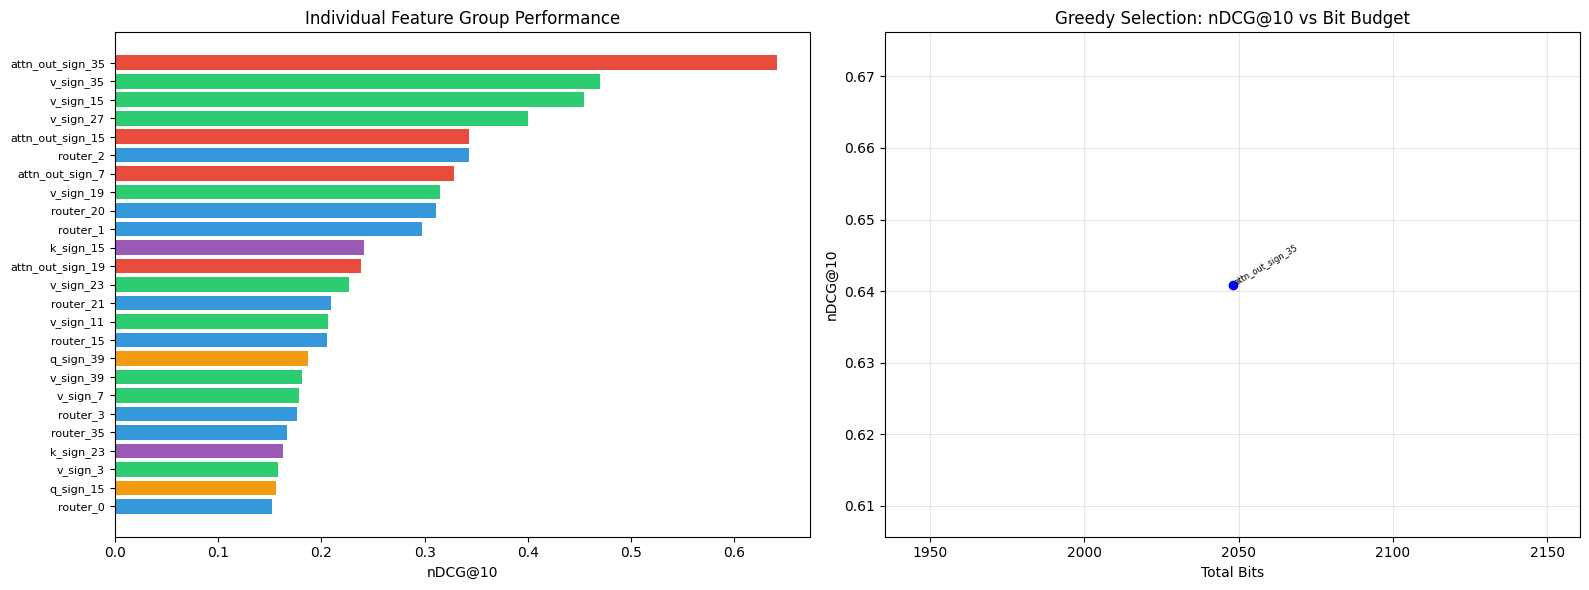

Saved: /content/binary_embed/results/feature_discovery.png


In [19]:
# @title Visualize results
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Individual group nDCG
ax = axes[0]
top_n = 25
names = [x[0] for x in individual_results[:top_n]]
ndcgs = [x[1] for x in individual_results[:top_n]]
colors = ['#e74c3c' if 'attn_out' in n else '#3498db' if 'router' in n
          else '#2ecc71' if 'v_sign' in n else '#9b59b6' if 'k_sign' in n
          else '#f39c12' if 'q_sign' in n else '#1abc9c'
          for n in names]
ax.barh(range(top_n), ndcgs, color=colors)
ax.set_yticks(range(top_n))
ax.set_yticklabels(names, fontsize=8)
ax.set_xlabel('nDCG@10')
ax.set_title('Individual Feature Group Performance')
ax.invert_yaxis()

# Plot 2: Greedy selection cumulative nDCG
ax = axes[1]
if selection_log:
    steps = [x["step"] for x in selection_log]
    ndcgs = [x["ndcg_at_10"] for x in selection_log]
    bits = [x["total_bits"] for x in selection_log]
    ax.plot(bits, ndcgs, 'bo-', markersize=6)
    for i, log in enumerate(selection_log[:10]):
        ax.annotate(log["group"], (bits[i], ndcgs[i]),
                    fontsize=6, rotation=30, ha='left')
    ax.set_xlabel('Total Bits')
    ax.set_ylabel('nDCG@10')
    ax.set_title('Greedy Selection: nDCG@10 vs Bit Budget')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(RESULTS_DIR / 'feature_discovery.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {RESULTS_DIR / 'feature_discovery.png'}")